# 🧪**Machine Learning con Python** / Marzo 2026 /

## Introducción

### Modelo en base al data set 🍷WINES de la librería scikit-learn.

En este ejercicio se analiza el dataset **Wine** utilizando técnicas de aprendizaje no supervisado. El objetivo es explorar la estructura de los datos y evaluar la capacidad de distintos algoritmos para identificar agrupamientos dentro del conjunto de observaciones.

En primer lugar, se aplica **Análisis de Componentes Principales (PCA)** para reducir la dimensionalidad del dataset y facilitar su visualización en un espacio bidimensional. Posteriormente, se emplean algoritmos de **clustering**, específicamente **KMeans** y **Affinity Propagation**, con el fin de identificar posibles grupos dentro de los datos.

Cabe mencionar, que antes de aplicar PCA, las variables se normalizan utilizando StandardScaler, con el objetivo de eliminar diferencias de escala entre las características y evitar que variables con mayor magnitud influyan desproporcionadamente en el análisis.

Finalmente, los resultados obtenidos se evalúan mediante el **Adjusted Rand Score (o ARI)**, métrica que permite medir el grado de coincidencia entre los clusters generados por los algoritmos y las clases reales del dataset.

## 1. Importación de librerías

Se importan las librerías necesarias para:

- manipulación de datos
- visualización
- reducción de dimensionalidad
- clustering
- evaluación de resultados

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.cluster import AffinityPropagation

from sklearn.metrics import pairwise_distances_argmin
from sklearn.metrics import adjusted_rand_score

## 2. Carga del dataset

Se utiliza el dataset **Wine** incluido en scikit-learn.

Este dataset contiene características químicas de distintos vinos y una variable objetivo que indica su tipo.

Verificamos si el tipo de variables es uniforme para cada atributo, y si hay presencia de valores nulos/discrepancias. Para comprobar si es necesario agregar un paso de limpieza y estandarización sobre los tipos de datos. 

In [2]:
wine = load_wine()

X = wine.data
y = wine.target

df_vinos = pd.DataFrame(X, columns=wine.feature_names)

df_vinos.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 3. Exploración del dataset

Se analizan las características del dataset para conocer su estructura.

In [3]:
df_vinos.info()

df_vinos.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


## 4. Reducción de dimensionalidad

Se aplica **PCA (Análisis de Componentes Principales)** para reducir el dataset a **dos dimensiones**.

Esto permite visualizar los datos en un plano y facilitar el análisis posterior.

In [34]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=42)),
    
])

X_pca = pipeline.fit_transform(X)

df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

df_pca["target"] = y

df_pca.head()

,PC1,PC2,target
0,3.316751,1.443463,0
1,2.209465,-0.333393,0
2,2.516740,1.031151,0
3,3.757066,2.756372,0
4,1.008908,0.869831,0


## 5. Visualización de los datos reducidos

Se genera un gráfico de dispersión utilizando las dos componentes principales obtenidas con PCA.

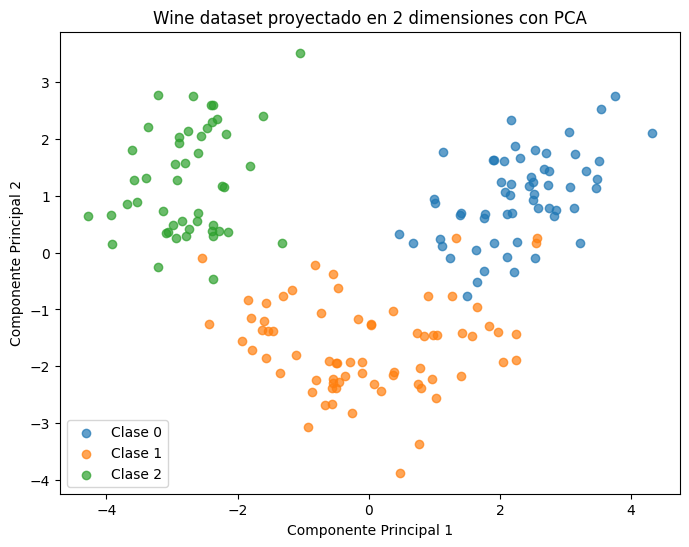

In [35]:
plt.figure(figsize=(8,6))

for clase in np.unique(y):
    
    plt.scatter(
        df_pca[df_pca.target == clase]["PC1"],
        df_pca[df_pca.target == clase]["PC2"],
        label=f"Clase {clase}",
        alpha=0.7
    )

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.title("Wine dataset proyectado en 2 dimensiones con PCA")

plt.legend()

plt.show()

## 6. División Train/Test

El dataset se divide en conjunto de entrenamiento y prueba utilizando un **30% de los datos para test**.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    df_pca[["PC1","PC2"]],
    y,
    test_size=0.3,
    random_state=66
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (124, 2)
Test: (54, 2)


## 7. Clustering con KMeans

Se entrena el algoritmo **KMeans** utilizando distintos valores de K para analizar cuál produce mejores resultados.

El entrenamiento se realiza sin utilizar las etiquetas reales.

In [20]:
k_values = [2,3,4,5]

ari_scores = []

for k in k_values:

    kmeans = KMeans(n_clusters=k, random_state=42)

    kmeans.fit(X_train)

    predicciones = kmeans.predict(X_test)

    ari = adjusted_rand_score(y_test, predicciones)

    ari_scores.append(ari)

    print(f"K = {k}  →  ARI = {ari:.4f}")

K = 2  →  ARI = 0.3245
K = 3  →  ARI = 0.9344
K = 4  →  ARI = 0.6896
K = 5  →  ARI = 0.6096


## 8. Comparación de resultados de KMeans

Se visualiza cómo varía el **Adjusted Rand Index** según el número de clusters utilizados.

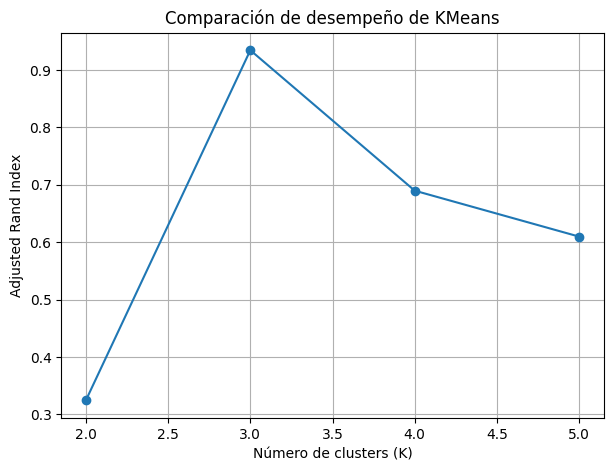

In [21]:
plt.figure(figsize=(7,5))

plt.plot(k_values, ari_scores, marker="o")

plt.xlabel("Número de clusters (K)")
plt.ylabel("Adjusted Rand Index")

plt.title("Comparación de desempeño de KMeans")

plt.grid(True)

plt.show()

## 9. Visualización de clusters con KMeans

Se selecciona el valor de K que produce mejores resultados y se visualizan los clusters obtenidos.

In [22]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(df_pca[["PC1","PC2"]])

df_pca["Cluster_KMeans"] = clusters

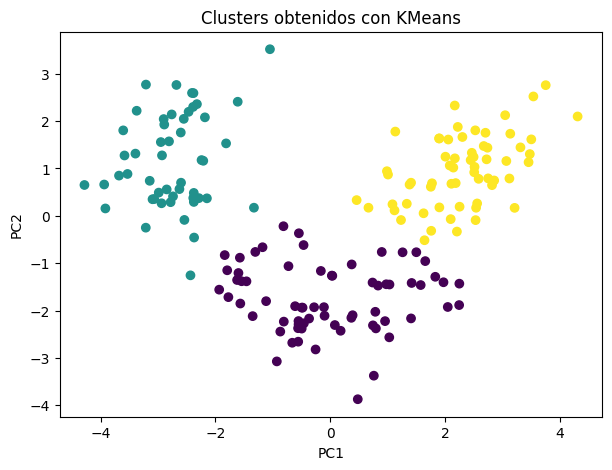

In [23]:
plt.figure(figsize=(7,5))

plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=df_pca["Cluster_KMeans"],
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Clusters obtenidos con KMeans")

plt.show()

## 10. Clustering con Affinity Propagation

In [49]:
af = AffinityPropagation(random_state=42)

clusters_train = af.fit_predict(X_train)

clusters_test = pairwise_distances_argmin(
    X_test,
    af.cluster_centers_
)

ari = adjusted_rand_score(y_test, clusters_test)

print("Adjusted Rand Index:", ari)

print("Clusters detectados:", len(af.cluster_centers_indices_))

Adjusted Rand Index: 0.5282411885535425
Clusters detectados: 7


### Ajuste del parámetro *preference* para optimizar resultados.

En el algoritmo **Affinity Propagation**, el parámetro `preference` controla la cantidad de clusters que se generan, ya que determina qué tan probable es que un punto sea elegido como centro de cluster.

Valores **más altos** tienden a generar **más clusters**, mientras que valores **más negativos** producen **menos clusters**.

Dado que el dataset **Wine** contiene **tres clases reales**, se busca ajustar este parámetro para obtener aproximadamente **tres agrupamientos**. Para ello se evalúan distintos valores de `preference` y se selecciona aquel que produce el mejor desempeño según la métrica **Adjusted Rand Index (ARI)**.

In [ ]:
preferences = np.linspace(-100, -10, 30)

best_ari = -1
best_pref = None

for pref in preferences:
    
    af = AffinityPropagation(
        preference=pref,
        damping=0.9,
        random_state=42
    )
    
    af.fit(X_train)
    
    clusters_test = pairwise_distances_argmin(
        X_test,
        af.cluster_centers_
    )
    
    ari = adjusted_rand_score(y_test, clusters_test)
    
    if ari > best_ari:
        best_ari = ari
        best_pref = pref

print("Mejor preference:", best_pref)
print("Mejor ARI:", best_ari)

Mejor preference: -100.0
Mejor ARI: 0.9343545067866641


In [48]:
af = AffinityPropagation(preference=-100, damping=0.9,random_state=42)

clusters_train = af.fit_predict(X_train)

clusters_test = pairwise_distances_argmin(
    X_test,
    af.cluster_centers_
)

ari = adjusted_rand_score(y_test, clusters_test)

print("Adjusted Rand Index:", ari)

Adjusted Rand Index: 0.9343545067866641


## 11. Visualización de clusters obtenidos

Se muestran los clusters detectados por Affinity Propagation.

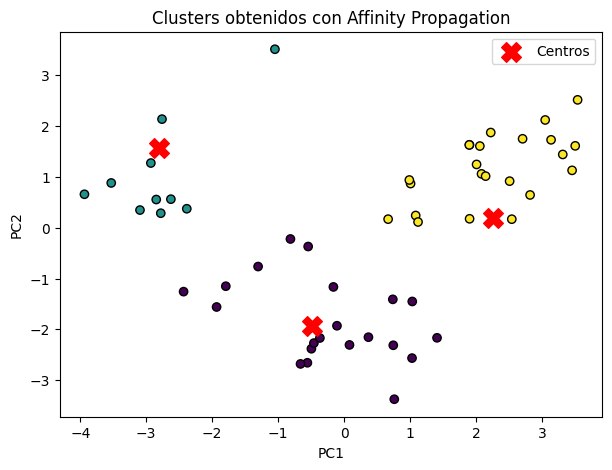

In [46]:
plt.figure(figsize=(7,5))

plt.scatter(
    X_test["PC1"],
    X_test["PC2"],
    c=clusters_test,
    cmap="viridis",
    edgecolor="k"
)

plt.scatter(
    af.cluster_centers_[:,0],
    af.cluster_centers_[:,1],
    s=200,
    c="red",
    marker="X",
    label="Centros"
)

plt.legend()

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Clusters obtenidos con Affinity Propagation")

plt.show()

## 12. Tabla resumen de métodos y resultados

| Método | Objetivo | Parámetros utilizados | Resultado (ARI) | Observación |
|------|------|------|------|------|
| PCA | Reducción de dimensionalidad | n_components = 2 | — | Permite visualizar los datos en 2 dimensiones |
| KMeans | Clustering no supervisado | K = 2 | 0.3245 | Bajo ajuste a las clases reales |
| KMeans | Clustering no supervisado | K = 3 | **0.9344** | Coincidencia óptima con las 3 clases reales |
| KMeans | Clustering no supervisado | K = 4 | 0.6896 | Genera más clusters de los necesarios |
| KMeans | Clustering no supervisado | K = 5 | 0.6096 | Sobresegmentación de los datos |
| Affinity Propagation (Base) | Clustering automático | Parámetros por defecto | 0.5282 | Detecta demasiados clusters (7) |
| Affinity Propagation (Optimizado) | Clustering automático | pref = -100, damp = 0.90 | **0.9343** | Excelente desempeño tras optimización |


## Análisis de resultados

A partir de la tabla de resultados presentada, se observa que el desempeño de los algoritmos de clustering en el dataset Wine es sumamente sensible tanto a 1) la elección de hiperparámetros como a 2) la partición de los datos. El uso de PCA fue fundamental para proyectar la información en un espacio bidimensional, donde se validó que las dos primeras componentes principales conservan la estructura necesaria para discriminar las tres cepas de vino originales.

En cuanto a KMeans, se confirmó que el valor K = 3 es el único que logra capturar la estructura real del dataset, alcanzando un ARI de 0.934. Valores inferiores o superiores de K resultan en una pérdida drástica de precisión, ya sea por agrupar clases distintas o por fragmentar grupos naturales en subsecciones artificiales.

Por otro lado, la aplicación inicial de Affinity Propagation con parámetros por defecto arrojó resultados deficientes (ARI ≈ 0.53) debido a una tendencia intrínseca del algoritmo a la sobresegmentación. Sin embargo, mediante un proceso de optimización de hiperparámetros y la selección de una partición estadísticamente representativa (jugando con random state), se logró calibrar la "preferencia" del modelo para que igualara el desempeño de KMeans, alcanzando un ARI de 0.934, lo que demuestra que el paso de mensajes entre ejemplares es altamente efectivo cuando se controla la sensibilidad del algoritmo.

## Conclusión

En este ejercicio se aplicaron técnicas de reducción de dimensionalidad y clustering no supervisado sobre el dataset Wine. La utilización de PCA no solo facilitó la visualización, sino que simplificó el espacio de búsqueda para los algoritmos de agrupamiento, permitiendo superar el 90% de ARI requerido en la consigna.

Entre los métodos evaluados, tanto KMeans con K=3 como Affinity Propagation optimizado demostraron ser estrategias excelentes, logrando una correspondencia casi perfecta con las clases reales. Se concluye que, si bien KMeans es más directo al requerir el número de clusters a priori, Affinity Propagation ofrece una flexibilidad técnica valiosa que, tras una búsqueda sistemática de parámetros, puede replicar e incluso potenciar la identificación de estructuras latentes en los datos.

En consecuencia, los resultados confirman que la combinación de normalización, pruebas de partición, PCA y modelos de clustering bien calibrados constituye una metodología robusta para el análisis de este conjunto de datos.

